# Importing Libraries

In [91]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import Perceptron
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [92]:
df=pd.read_csv(r"C:\Users\HP\Downloads\archive (4)\mnist_train.csv")
df_test=pd.read_csv(r"C:\Users\HP\Downloads\archive (4)\mnist_test.csv")

In [93]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
df.shape

(60000, 785)

In [95]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='str', length=785)

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [97]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

# Preprocessing

In [98]:
X_train=df.drop('label',axis=1).values
y_train=df['label'].values
X_test=df_test.drop('label',axis=1).values
y_test=df_test['label'].values

In [99]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [100]:

X_train_img=X_train.reshape(-1,28,28)
X_test_img=X_test.reshape(-1,28,28)

In [101]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

## One Hot Encoding

In [102]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

# Perceptron

In [103]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
    ])

In [104]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [105]:
history_perce=perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8083 - loss: 0.7910 - val_accuracy: 0.8809 - val_loss: 0.4823
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8802 - loss: 0.4573 - val_accuracy: 0.8940 - val_loss: 0.4008
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8905 - loss: 0.4036 - val_accuracy: 0.9012 - val_loss: 0.3675
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8966 - loss: 0.3769 - val_accuracy: 0.9056 - val_loss: 0.3493
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9004 - loss: 0.3600 - val_accuracy: 0.9096 - val_loss: 0.3371


In [106]:
acc_perce=perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]
print(acc_perce)

0.909600019454956


# ANN

In [114]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [108]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [109]:
history_ann=ann.fit(X_train_img,y_train_cat,validation_data=(X_test_img,y_test_cat),epochs=5,batch_size=32,verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9290 - loss: 0.2449 - val_accuracy: 0.9619 - val_loss: 0.1268
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9691 - loss: 0.1020 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0728 - val_accuracy: 0.9732 - val_loss: 0.0837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9825 - loss: 0.0545 - val_accuracy: 0.9743 - val_loss: 0.0827
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0417 - val_accuracy: 0.9775 - val_loss: 0.0806


In [110]:
acc_ann=ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]
print(acc_ann)

0.9775000214576721


# CNN

In [115]:
X_train_img=X_train.reshape(-1,28,28,1)
X_test_img=X_test.reshape(-1,28,28,1)

In [116]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu') ,
    Dropout(0.5),
    Dense(10,activation='softmax')
    
])

In [117]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [118]:
history_cnn=cnn.fit(X_train_img,y_train_cat,validation_data=(X_test_img,y_test_cat),epochs=5,batch_size=32,verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9381 - loss: 0.2032 - val_accuracy: 0.9827 - val_loss: 0.0535
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9769 - loss: 0.0795 - val_accuracy: 0.9884 - val_loss: 0.0346
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9827 - loss: 0.0578 - val_accuracy: 0.9904 - val_loss: 0.0295
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9863 - loss: 0.0465 - val_accuracy: 0.9905 - val_loss: 0.0276
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9906 - val_loss: 0.0289


In [121]:
acc_cnn=cnn.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_cnn

0.9905999898910522

# Viewing it visually through image

In [128]:
perceptron_pred = np.argmax(perceptron.predict(X_test_img), axis=1)

# ANN predictions
ann_pred = np.argmax(ann.predict(X_test_img), axis=1)

# CNN predictions
cnn_pred = np.argmax(cnn.predict(X_test_img), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


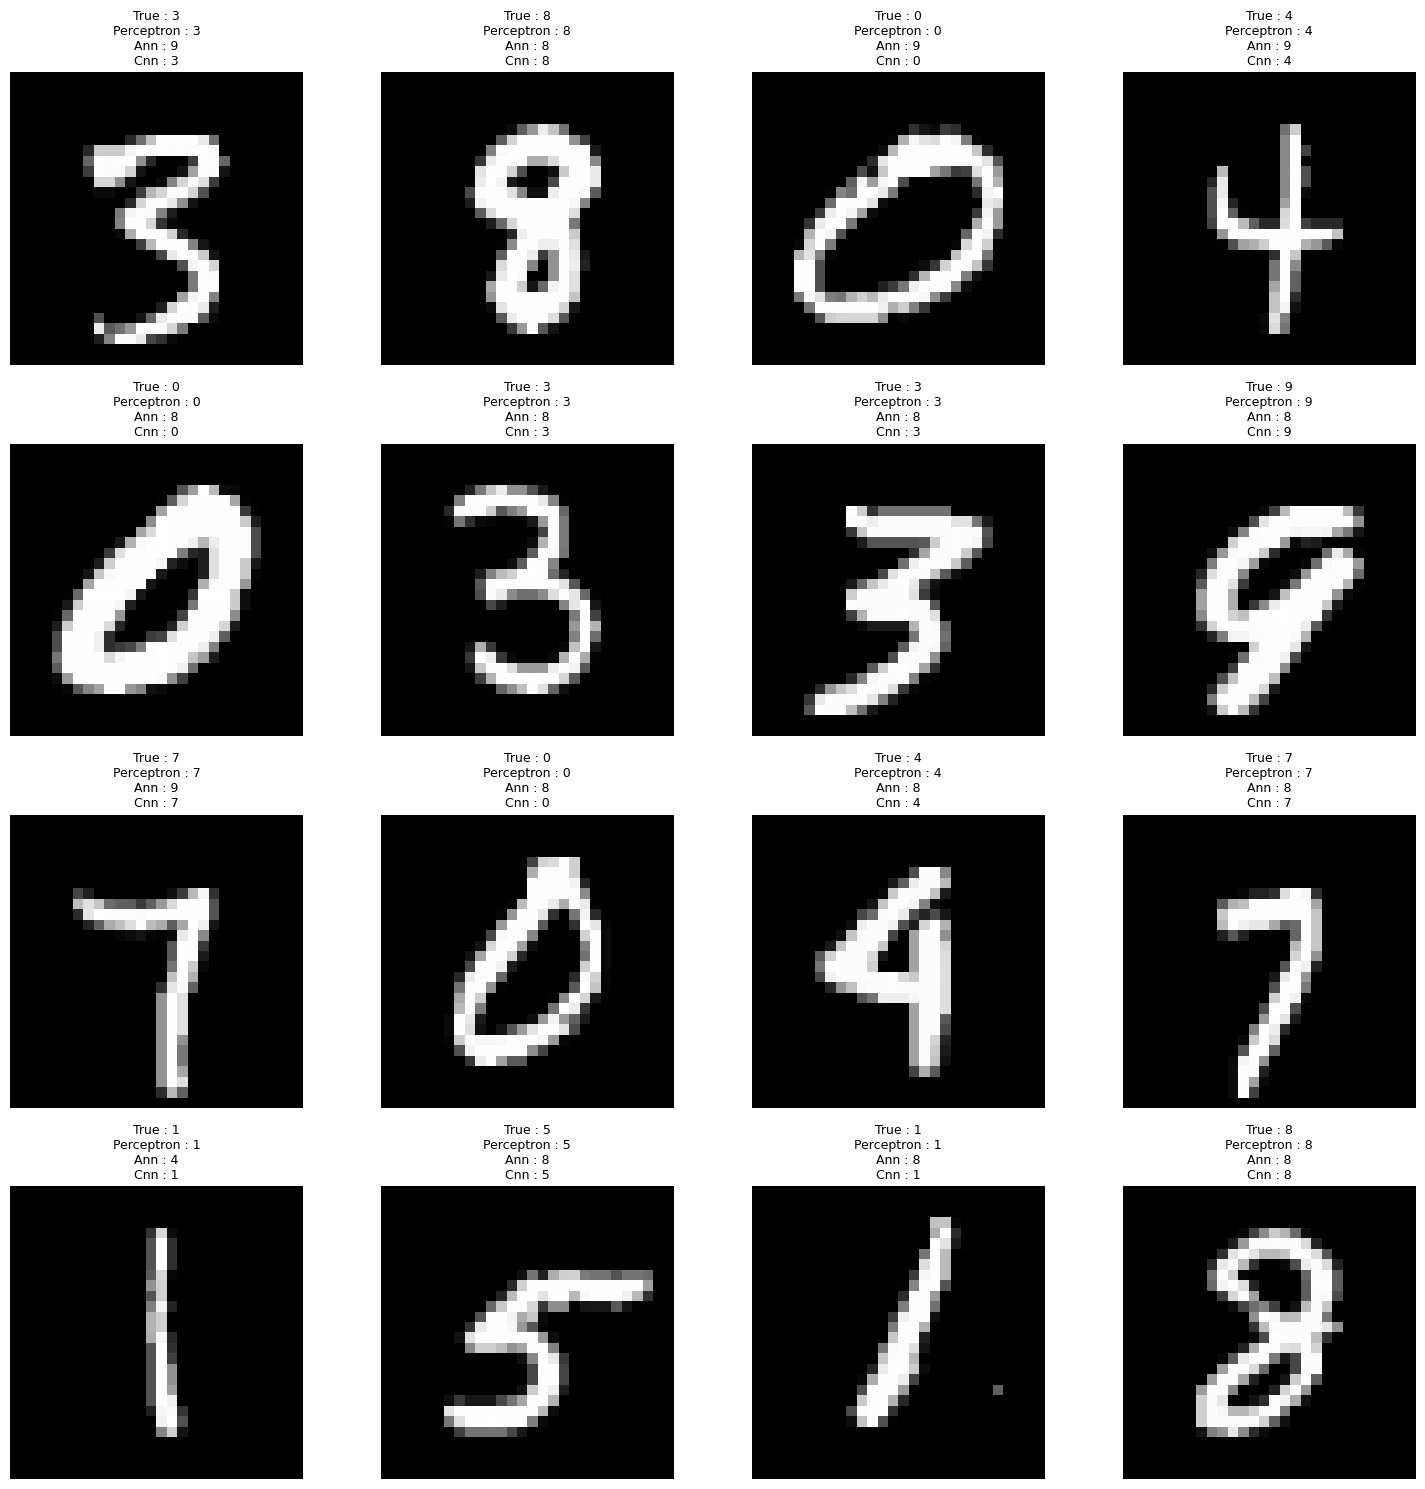

In [129]:
plt.figure(figsize=(15,15))

indices = np.random.choice(len(X_test), 16, replace=False)

for i, idx in enumerate(indices):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test_img[idx].reshape(28,28), cmap='gray')

    plt.title(
        f"True : {y_test[idx]}\n"
        f"Perceptron : {perceptron_pred[idx]}\n"
        f"Ann : {ann_pred[idx]}\n"
        f"Cnn : {cnn_pred[idx]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()